In [39]:
import pandas as pd
import yaml
import os

DATA_DIR = "D:\\data\\DATA3"

users_path = os.path.join(DATA_DIR, "users.csv")
users_df = pd.read_csv(users_path)
users_df = users_df.drop_duplicates()

orders_path = os.path.join(DATA_DIR, "orders.parquet")
orders_df = pd.read_parquet(orders_path)
orders_df = orders_df.drop_duplicates()

books_path = os.path.join(DATA_DIR, "books.yaml")
with open(books_path, 'r') as file:
    books_data = yaml.safe_load(file)

books_df = pd.DataFrame(books_data)
books_df.columns = [col.strip(':') if isinstance(col, str) else col for col in books_df.columns]
books_df = books_df.drop_duplicates()

print("Users shape:", users_df.shape)
print("Orders shape:", orders_df.shape)
print("Books shape:", books_df.shape)

Users shape: (3466, 5)
Orders shape: (8933, 7)
Books shape: (762, 6)


In [40]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3466 entries, 0 to 3465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3466 non-null   int64 
 1   name     3466 non-null   object
 2   address  3344 non-null   object
 3   phone    3466 non-null   object
 4   email    3466 non-null   object
dtypes: int64(1), object(4)
memory usage: 135.5+ KB


In [41]:
count1 = (users_df['address']=="").sum()
count2 = (users_df['address']=="NULL").sum()
count3 = users_df['address'].isna().sum()
print(count1)
print(count2)
print(count3)

0
0
122


In [42]:
users_df['address'] = users_df['address'].fillna('Unknown')

In [43]:
count = users_df.isna().sum()
print(count)

id         0
name       0
address    0
phone      0
email      0
dtype: int64


In [44]:
count1 = (users_df.values =="").sum()
count2 = (users_df.values=="NULL").sum()
print(count1)
print(count2)

0
0


In [45]:
users_df

,id,name,address,phone,email
0,47856,Tammie Mayer,"Apt. 371 1875 Gusikowski Stravenue, Moenland, ...",163.212.2656,maire.larson@runolfsdottir-mclaughlin.example
1,49394,Evia Yost,"22610 Mildred Green, Pagacbury, AZ 19393-2103",778.926.6707,byron@johnston.test
2,48386,Margery Gorczany,"Apt. 884 349 Renner Lane, East Darren, NC 30837",992 375 5021,cletus@baumbach.test
3,49547,Edris Kshlerin,"Suite 498 24711 Bechtelar Extensions, Ryanvill...",747.537.2209,leonore@gleason.test
4,50512,Meghan Thiel,"125 Rodger Drive, Rogahnborough, VT 96988-4596",(631) 765-7676,cristine@bayer.test
...,...,...,...,...,...
3461,49835,Amb. Alina Torp,"Apt. 847 503 Everett Gardens, Lynseyborough, G...",285.112.5843,tynisha_padberg@jerde.test
3462,49916,Ellis MacGyver,"8330 Cassin Motorway, North Parthenia, VT 1280...",(848) 241-2825,tyson@okeefe.test
3463,48029,Ngan Schowalter,"Suite 593 74004 Renner Walks, Port Setsuko, CO...",(720) 361-2960,ariel@lindgren.test
3464,48494,Cristine Nikolaus,"Suite 954 82413 Medhurst Walk, Kenethland, MT ...",997.324.8132,cathie@ziemann.test


In [46]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          8933 non-null   int64 
 1   user_id     8933 non-null   int64 
 2   book_id     8933 non-null   int64 
 3   quantity    8933 non-null   int32 
 4   unit_price  8933 non-null   object
 5   timestamp   8933 non-null   object
 6   shipping    6721 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 453.8+ KB


In [47]:
count1 = (orders_df['shipping']=="").sum()
count2 = (orders_df['shipping']=="NULL").sum()
count3 = orders_df['shipping'].isna().sum()
print(count1)
print(count2)
print(count3)

2215
2188
2212


In [48]:
import numpy as np
orders_df = orders_df.replace("", np.nan)
orders_df = orders_df.replace("NULL", np.nan)

In [49]:
count4 = orders_df.isna().sum()
print(count4)

id               0
user_id          0
book_id          0
quantity         0
unit_price       0
timestamp        0
shipping      6615
dtype: int64


In [50]:
orders_df['shipping'] = orders_df['shipping'].fillna('Unknown')

In [51]:
from dateutil import parser
orders_df['date'] = orders_df['timestamp'].apply(
    lambda x: parser.parse(x.replace(';', ' ').replace(',', ' ')).date() if pd.notnull(x) else pd.NaT
)

c:\Users\Samiz\anaconda3\envs\myenv\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname M identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [52]:
orders_df

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date
0,80941,47864,21550,1,67.0 €,2025-01-11 09:50:11 PM,Unknown,2025-01-11
1,81245,47864,22052,2,EUR26.99,2024-03-27T07:46:55.055,Unknown,2024-03-27
2,78477,48918,21367,1,30 $,"11:17:51 PM, 29-JUN-2025",Unknown,2025-06-29
3,86303,48092,21724,1,18 $,09:29;11/06/24,Unknown,2024-11-06
4,81990,48418,21441,1,USD 24.99,2024-09-16;03:05:39 pm,Unknown,2024-09-16
...,...,...,...,...,...,...,...,...
8928,85378,47966,21498,3,20.25 $,"04:14, 15-Dec-2024",Unknown,2024-12-15
8929,83069,49592,21437,1,$54.50,"25-FEB-2025,05:47:53 P.M.",Unknown,2025-02-25
8930,80042,49026,21583,5,59.25$,2024-11-04 17:09,Unknown,2024-11-04
8931,79620,48922,21541,2,31.50 €,"08:55:55 am, 2024-07-20",Unknown,2024-07-20


In [53]:
import re
import pandas as pd

def convert_to_usd(price_val):
    if pd.isna(price_val):
        return 0.0
        
    price_str = str(price_val).strip()
    is_euro = '€' in price_str or 'EUR' in price_str.upper()
    price_str = re.sub(r'(\d+)[$¢€](\d+)¢?', r'\1.\2', price_str)
    numeric_str = re.sub(r'[^\d.]', '', price_str)

    if not numeric_str:
        return 0.0

    if is_euro:
        val = float(numeric_str) * 1.2
    else:
        val = float(numeric_str)
        
    return val

orders_df['unit_price_usd'] = orders_df['unit_price'].apply(convert_to_usd)
orders_df['paid_price'] = (orders_df['quantity'] * orders_df['unit_price_usd']).round(2)
print(orders_df[['quantity', 'unit_price', 'unit_price_usd', 'paid_price']].tail(50))

      quantity unit_price  unit_price_usd  paid_price
8883         1  51.00 USD          51.000       51.00
8884         2    21.25 €          25.500       51.00
8885         1    71.00 €          85.200       85.20
8886         1  USD 14.75          14.750       14.75
8887         1     75.EUR          90.000       90.00
8888         1  59.99 EUR          71.988       71.99
8889         1       69 $          69.000       69.00
8890         1  EUR 24.00          28.800       28.80
8891         5     53.25$          53.250      266.25
8892         1   USD57.75          57.750       57.75
8893         3  21.99 USD          21.990       65.97
8894         1     26.00€          31.200       31.20
8895         2      25USD          25.000       50.00
8896         1    $ 30.25          30.250       30.25
8897         1   USD76.75          76.750       76.75
8898         1    55.75 $          55.750       55.75
8899         1     $48.75          48.750       48.75
8900         1   USD69.99   

In [54]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         762 non-null    int64 
 1   title      762 non-null    object
 2   author     762 non-null    object
 3   genre      762 non-null    object
 4   publisher  759 non-null    object
 5   year       760 non-null    object
dtypes: int64(1), object(5)
memory usage: 35.8+ KB


In [55]:
count1 = (books_df['publisher']=="").sum()
count2 = (books_df['publisher']=="NULL").sum()
count3 = books_df['publisher'].isna().sum()
print(count1)
print(count2)
print(count3)

8
1
3


In [56]:
books_df = books_df.replace("", np.nan)
books_df = books_df.replace("NULL", np.nan)

In [59]:
count = books_df.isna().sum()
print(count)

id           0
title        0
author       0
genre        0
publisher    0
year         0
dtype: int64


In [58]:
books_df['publisher'] = books_df['publisher'].fillna('Unknown')
books_df['year'] = books_df['year'].fillna('Unknown')

In [60]:
books_df

,id,title,author,genre,publisher,year
0,21778,Call of Duty: World at War,Elmer Parker,Mythopoeia,Orion Books,2003
1,21374,WarioWare: Touched!,Ms. Kami Prosacco,Mythology,St. Martin's Press,1951
2,21457,Titanic: Music from the Motion Picture,Zoila Christiansen,Historical fiction,"Farrar, Straus & Giroux",2009
3,21881,Flashdance: Original Soundtrack from the Motio...,"Joseph Raynor, Ja Ankunding II",Metafiction,Pen and Sword Books,2024
4,21446,Riot!,Louanne Cruickshank,Mystery,Bellevue Literary Press,1987
...,...,...,...,...,...,...
757,22033,Heat,"Lela Emard, Keeley Hand, Coy Streich",Tall tale,Parachute Publishing,1994
758,21814,The Lion King,Myrl Miller,Mystery,Hodder Headline,1984
759,21548,Shadow Tactics: Blade of the Shogun,Casey Bode,Comic/Graphic Novel,Focal Press,1983
760,21990,Fear and Trembling,Ozzie Jast,Mystery,University of Akron Press,2024


In [61]:
daily_revenue = orders_df.groupby('date')['paid_price'].sum().reset_index()
daily_revenue.rename(columns={'paid_price': 'daily_revenue'}, inplace=True)
print(daily_revenue)

           date  daily_revenue
0    2024-01-04         141.17
1    2024-01-06          48.00
2    2024-01-07          42.50
3    2024-01-09          75.00
4    2024-01-11          95.75
..          ...            ...
627  2025-11-05          64.25
628  2025-11-12          71.00
629  2025-12-01          73.99
630  2025-12-04         101.25
631  2025-12-05          42.60

[632 rows x 2 columns]


In [62]:
top_5_revenue_days = daily_revenue.sort_values(by='daily_revenue', ascending=False).head(5)
print("Top 5 Days by Revenue:")
print(top_5_revenue_days.to_string(index=False))

Top 5 Days by Revenue:
      date  daily_revenue
2024-11-16        3688.19
2025-01-31        3341.99
2024-10-26        3127.92
2024-11-12        3034.54
2024-11-01        2954.02


In [63]:
def normalize(col):
    return col.astype(str).str.strip().str.lower()

users_df['name'] = normalize(users_df['name'])
users_df['address'] = normalize(users_df['address'])
users_df['phone'] = normalize(users_df['phone'])
users_df['email'] = normalize(users_df['email'])

n = len(users_df)
parent = list(range(n))

def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[py] = px

def merge_on_columns(cols):
    groups = users_df.groupby(cols).indices
    for _, indices in groups.items():
        indices = list(indices)
        for i in range(1, len(indices)):
            union(indices[0], indices[i])

merge_on_columns(['name', 'address', 'phone'])
merge_on_columns(['name', 'address', 'email'])
merge_on_columns(['name', 'phone', 'email'])
merge_on_columns(['address', 'phone', 'email'])

unique_users = len(set(find(i) for i in range(n)))
print("Number of real unique users:", unique_users)

Number of real unique users: 3290


In [64]:
def get_author_set(author_string):
    raw_authors = str(author_string).split(',')
    cleaned_authors = [author.strip() for author in raw_authors if author.strip()]
    sorted_authors = sorted(cleaned_authors)
    return tuple(sorted_authors)

normalized_author_sets = books_df['author'].apply(get_author_set)
unique_sets_count = normalized_author_sets.nunique()

print(f"Number of unique sets of authors: {unique_sets_count}")
print("\nSample of unique author sets:")
print(pd.Series(normalized_author_sets.unique()))

Number of unique sets of authors: 268

Sample of unique author sets:
0                                        (Elmer Parker,)
1                                   (Ms. Kami Prosacco,)
2                                  (Zoila Christiansen,)
3                       (Ja Ankunding II, Joseph Raynor)
4                                 (Louanne Cruickshank,)
                             ...                        
263                  (Phil Hettinger Ret., Verna Skiles)
264    (Guadalupe Batz Ret., Kristeen Kessler CPA, Ma...
265                   (Farah Rohan II, Mitch Gusikowski)
266                                     (Billie Ernser,)
267                               (Phil Hettinger Ret.,)
Length: 268, dtype: object


In [65]:
books_df['author_set'] = books_df['author'].apply(get_author_set)
merged_df = orders_df.merge(books_df[['id', 'author_set']], left_on='book_id', right_on='id', how='inner')
author_set_sales = merged_df.groupby('author_set')['quantity'].sum().reset_index()
top_author_sets = author_set_sales.sort_values(by='quantity', ascending=False)
most_popular = top_author_sets.iloc[0]

print("Top 5 Author Sets by Sales")
print(top_author_sets.head(5).to_string(index=False))
print(f"The most popular author set is {most_popular['author_set']}")

Top 5 Author Sets by Sales
                            author_set  quantity
(Coy Streich, Keeley Hand, Lela Emard)       159
                     (Benjamin Mills,)       156
                       (Karisa Kozey,)       150
        (Clyde Jacobson, Mohamed Dach)       148
                  (Jeffry Nolan Ret.,)       143
The most popular author set is ('Coy Streich', 'Keeley Hand', 'Lela Emard')


In [66]:
users_df['real_user_id'] = [users_df.at[find(i), 'id'] for i in range(n)]
id_to_real_id = dict(zip(users_df['id'], users_df['real_user_id']))
orders_df['real_user_id'] = orders_df['user_id'].map(id_to_real_id)

valid_orders = orders_df.dropna(subset=['real_user_id'])
user_spending = valid_orders.groupby('real_user_id')['paid_price'].sum().reset_index()

top_customer = user_spending.sort_values(by='paid_price', ascending=False).iloc[0]
top_real_user_id = top_customer['real_user_id']
best_buyer_aliases = users_df[users_df['real_user_id'] == top_real_user_id]['id'].tolist()

print(f"Best buyer (user_ids): {best_buyer_aliases}")

Best buyer (user_ids): [49715, 50963]


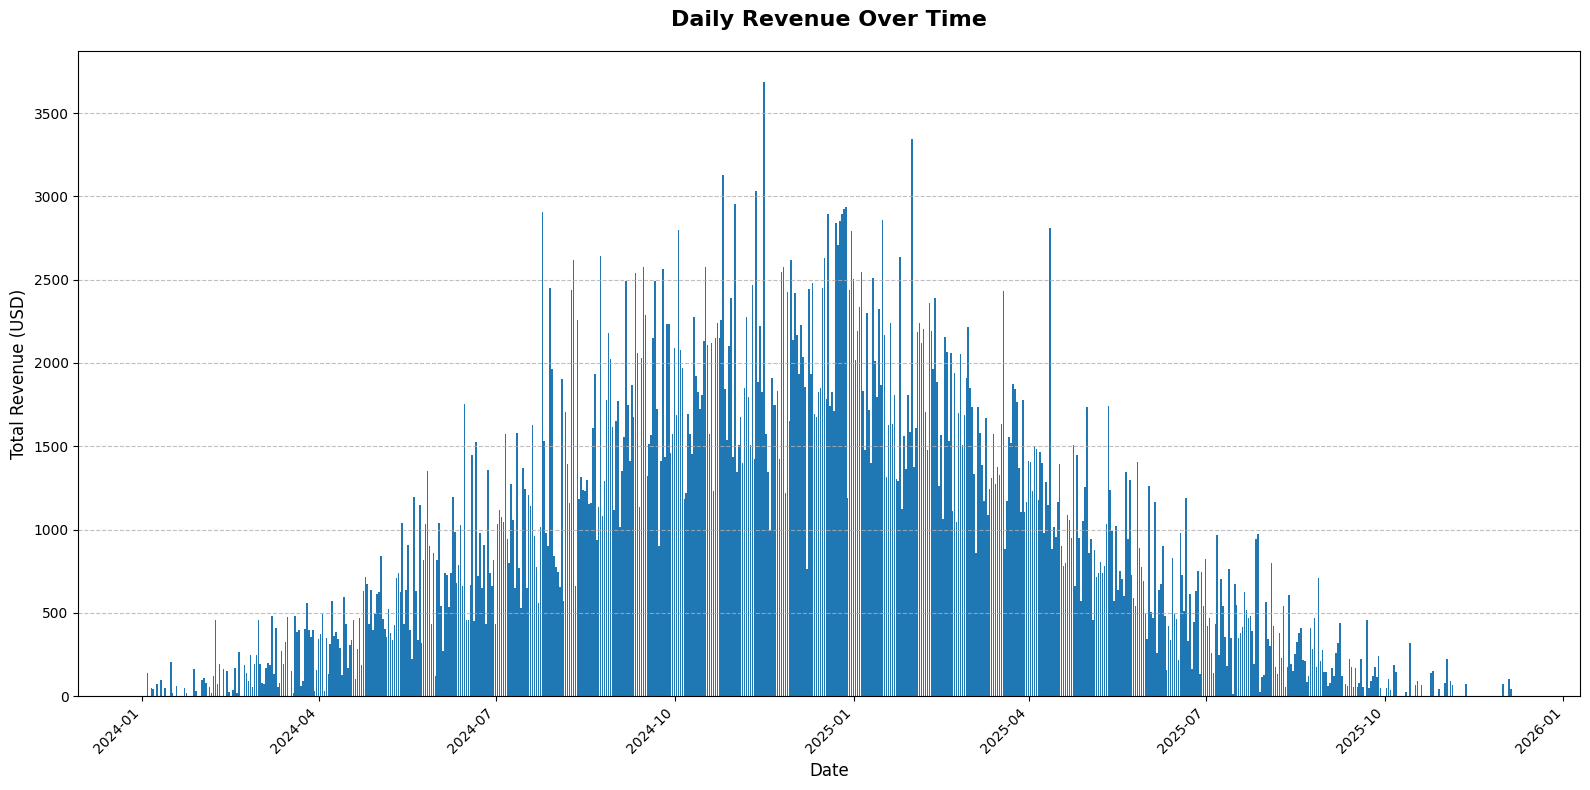

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(
    daily_revenue['date'], 
    daily_revenue['daily_revenue'], 
    color='#1f77b4'
)

ax.set_title('Daily Revenue Over Time', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.8, axis='y')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [68]:
import json

dataset_name = "DATA3"
daily_revenue.to_csv(f'daily_revenue_{dataset_name}.csv', index=False)
top_5_revenue_days.to_csv(f'top_5_revenue_{dataset_name}.csv', index=False)

metrics = {
    "unique_users": int(unique_users),
    "unique_author_sets": int(unique_sets_count),
    "most_popular_author": str(most_popular['author_set']),
    "best_buyer_aliases": best_buyer_aliases 
}

with open(f'dashboard_metrics_{dataset_name}.json', 'w') as f:
    json.dump(metrics, f)